# Product Name Normalization & Feature Extraction

This notebook implements comprehensive preprocessing to prepare product names for matching and clustering.

## Pipeline Steps:
1. **Supermarket Brand Extraction** - Extract and remove store-specific prefixes
2. **Quality/Value Tier Classification** - Identify product tier (Premium/Standard/Value)
3. **Known Brand Extraction** - Extract well-known commercial brands
4. **Multipack Extraction** - Extract pack size/quantity information
5. **Unit Extraction & Standardization** - Extract and normalize weight/volume units
6. **Attribute Extraction** - Extract product attributes (organic, gluten-free, etc.)
7. **Descriptor Extraction** - Extract cooking methods, flavors, types
8. **Core Product Name Generation** - Create cleaned, normalized product identifier

The output will be a fully normalized dataset ready for hybrid matching.

In [1]:
# Setup and Data Loading

import pandas as pd
import numpy as np
import re
from typing import Tuple, List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# Load the raw data
df = pd.read_csv('data/raw.csv')

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Dataset loaded: (65473, 8)
Columns: ['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date', 'category', 'own_brand']

First few rows:
  supermarket  prices_(£)  prices_unit_(£) unit  \
0        ASDA        4.75             19.8   kg   
1        ASDA        2.00             26.7   kg   
2        ASDA        5.00             20.8   kg   
3        ASDA        3.50             15.4   kg   
4        ASDA        3.50             15.4   kg   

                                               names      date category  \
0             Tassimo Cadbury Hot Chocolate Pods x 8  20240413   drinks   
1     Taylors of Harrogate Hot Lava Java Coffee Bags  20240413   drinks   
2  Tassimo Limited Edition Cadbury Orange Hot Cho...  20240413   drinks   
3         ASDA Extra Special Brazilian Ground Coffee  20240413   drinks   
4           ASDA Extra Special Espresso Coffee Beans  20240413   drinks   

  own_brand  
0     False  
1     False  
2     False  
3      True  
4      True  

Data 

In [2]:
## 1. Define Extraction Patterns and Vocabularies

# Supermarket-specific brand prefixes (ordered by length for proper matching)
SUPERMARKET_BRANDS = {
    'Tesco': [
        'Tesco Finest',
        'Tesco Everyday Value', 
        'Tesco Free From',
        'Tesco Organic',
        'Tesco',
    ],
    'ASDA': [
        'ASDA Extra Special',
        'Asda Extra Special',
        'ASDA Smart Price',
        'Asda Smart Price',
        'ASDA Chosen By You',
        'Asda Chosen By You',
        'ASDA Free From',
        'Asda Free From',
        'ASDA',
        'Asda',
    ],
    'Morrisons': [
        'Morrisons The Best',
        'Morrisons Savers',
        'Morrisons Free From',
        'Morrisons Organic',
        'M Kitchen',
        'Morrisons',
    ],
    'Sains': [
        'Sainsbury\'s Taste the Difference',
        'Sainsburys Taste the Difference',
        'Taste the Difference',
        'Sainsbury\'s Basics',
        'Sainsburys Basics',
        'Sainsbury\'s Free From',
        'Sainsburys Free From',
        'SO Organic',
        'Sainsbury\'s',
        'Sainsburys',
    ]
}

# Quality and Value tier keywords
QUALITY_TIERS = {
    'premium': ['finest', 'extra special', 'taste the difference', 'the best', 'premium', 
                'luxury', 'deluxe', 'superior', 'select'],
    'value': ['value', 'basics', 'savers', 'smart price', 'everyday value', 'everyday', 
              'essential', 'essentials']
}

# Well-known commercial brands (comprehensive list)
KNOWN_BRANDS = [
    # Beverages
    'coca-cola', 'coca cola', 'pepsi', 'fanta', 'sprite', 'dr pepper', '7up', 'schweppes',
    'ribena', 'robinsons', 'tropicana', 'innocent', 'capri sun', 'vimto', 'lucozade',
    'red bull', 'monster', 'relentless',
    
    # Coffee & Tea
    'nescafe', 'twinings', 'tetley', 'pg tips', 'yorkshire tea', 'clipper', 'pukka',
    'costa', 'starbucks', 'lavazza', 'illy', 'kenco', 'douwe egberts', 'tassimo',
    
    # Dairy
    'anchor', 'lurpak', 'flora', 'benecol', 'philadelphia', 'dairylea', 'babybel',
    'muller', 'müller', 'yoplait', 'activia', 'danone', 'alpro', 'oatly',
    
    # Food brands
    'heinz', 'kellogg\'s', 'kelloggs', 'nestle', 'cadbury', 'mars', 'snickers',
    'walkers', 'pringles', 'doritos', 'mccoys', 'quavers', 'wotsits',
    'ben & jerry\'s', 'ben & jerrys', 'haagen-dazs', 'haagen dazs',
    'warburtons', 'hovis', 'kingsmill', 'allinson',
    'uncle ben\'s', 'uncle bens', 'dolmio', 'loyd grossman',
    'sharwood\'s', 'sharwoods', 'pataks', 'blue dragon',
    'birdseye', 'birds eye', 'aunt bessie\'s', 'aunt bessies',
    'youngs', 'john west', 'princes',
    'pukka pies', 'charlie bigham\'s', 'charlie bighams',
    'quorn', 'linda mccartney', 'richmond',
    'andrex', 'kleenex', 'regina', 'cushelle',
    'persil', 'ariel', 'fairy', 'comfort', 'lenor',
    'colgate', 'gillette', 'dove', 'nivea',
    'paxo', 'bisto', 'oxo', 'knorr', 'maggi',
    'branston', 'colman\'s', 'colmans', 'marmite', 'bovril',
]

# Attribute keywords
ATTRIBUTES = {
    'organic': ['organic', 'bio', 'soil association'],
    'free_from': ['gluten free', 'dairy free', 'lactose free', 'wheat free', 'free from'],
    'diet': ['vegan', 'vegetarian', 'plant-based', 'plant based', 'low fat', 'reduced fat', 
             'fat free', 'sugar free', 'no added sugar', 'low sugar', 'light', 'lite'],
    'ethical': ['fairtrade', 'fair trade', 'free range', 'freedom food', 'rspca assured'],
    'preparation': ['ready to eat', 'ready to cook', 'ready meal', 'meal for one', 
                   'microwaveable', 'oven ready'],
}

# Descriptor keywords (cooking methods, flavors, types)
DESCRIPTORS = {
    'cooking_method': ['roasted', 'grilled', 'baked', 'fried', 'smoked', 'steamed', 
                      'poached', 'bbq', 'barbecue', 'chargrilled'],
    'texture': ['crunchy', 'crispy', 'smooth', 'chunky', 'creamy', 'thick', 'thin'],
    'flavor': ['mild', 'medium', 'hot', 'spicy', 'sweet', 'savoury', 'salty', 'tangy'],
    'form': ['sliced', 'diced', 'chopped', 'whole', 'halved', 'quartered', 'peeled',
            'shredded', 'grated', 'ground', 'crushed', 'powder', 'paste'],
}

print("✓ Pattern dictionaries defined")
print(f"  Supermarkets: {len(SUPERMARKET_BRANDS)}")
print(f"  Known brands: {len(KNOWN_BRANDS)}")
print(f"  Quality tiers: {sum(len(v) for v in QUALITY_TIERS.values())}")
print(f"  Attributes: {sum(len(v) for v in ATTRIBUTES.values())}")
print(f"  Descriptors: {sum(len(v) for v in DESCRIPTORS.values())}")

✓ Pattern dictionaries defined
  Supermarkets: 4
  Known brands: 111
  Quality tiers: 17
  Attributes: 31
  Descriptors: 38


In [3]:
## 2. Supermarket Brand Extraction Function

def extract_supermarket_brand(name: str, supermarket: str) -> Tuple[Optional[str], str]:
    """
    Extract supermarket-specific brand prefix from product name.
    
    Args:
        name: Product name
        supermarket: Supermarket name
        
    Returns:
        Tuple of (extracted_brand, remaining_name)
    """
    if pd.isna(name):
        return None, ""
    
    name_str = str(name).strip()
    prefixes = SUPERMARKET_BRANDS.get(supermarket, [])
    
    # Try each prefix (already sorted by length, longest first)
    for prefix in prefixes:
        # Case-insensitive matching at the start of the string
        pattern = re.compile(r'^' + re.escape(prefix) + r'\b', re.IGNORECASE)
        if pattern.match(name_str):
            remaining = pattern.sub('', name_str).strip()
            return prefix, remaining
    
    return None, name_str


# Test the function
test_cases = [
    ("Tesco Finest Colombian Coffee", "Tesco"),
    ("ASDA Extra Special Smoked Salmon", "ASDA"),
    ("Morrisons The Best Pork Sausages", "Morrisons"),
    ("Heinz Baked Beans", "Tesco"),
]

print("Testing supermarket brand extraction:")
print("-" * 80)
for name, supermarket in test_cases:
    brand, remaining = extract_supermarket_brand(name, supermarket)
    print(f"Original: {name}")
    print(f"  Brand: {brand}")
    print(f"  Remaining: {remaining}")
    print()

Testing supermarket brand extraction:
--------------------------------------------------------------------------------
Original: Tesco Finest Colombian Coffee
  Brand: Tesco Finest
  Remaining: Colombian Coffee

Original: ASDA Extra Special Smoked Salmon
  Brand: ASDA Extra Special
  Remaining: Smoked Salmon

Original: Morrisons The Best Pork Sausages
  Brand: Morrisons The Best
  Remaining: Pork Sausages

Original: Heinz Baked Beans
  Brand: None
  Remaining: Heinz Baked Beans



In [4]:
## 3. Quality/Value Tier Extraction Function

def extract_tier(name: str) -> Tuple[Optional[str], Optional[str], str]:
    """
    Extract quality or value tier from product name.
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (tier_type, tier_keyword, remaining_name)
        tier_type: 'premium', 'value', or None
    """
    if pd.isna(name):
        return None, None, ""
    
    name_str = str(name).strip()
    name_lower = name_str.lower()
    
    # Check for quality tiers (longest first to match multi-word phrases)
    for tier_type, keywords in QUALITY_TIERS.items():
        for keyword in sorted(keywords, key=len, reverse=True):
            # Match as whole word/phrase
            pattern = re.compile(r'\b' + re.escape(keyword) + r'\b', re.IGNORECASE)
            match = pattern.search(name_str)
            if match:
                # Remove the matched tier keyword
                remaining = pattern.sub('', name_str).strip()
                # Clean up multiple spaces
                remaining = re.sub(r'\s+', ' ', remaining)
                return tier_type, keyword, remaining
    
    return None, None, name_str


# Test the function
test_cases = [
    "Extra Special Colombian Coffee",
    "Finest Scottish Salmon",
    "Basics White Bread",
    "Everyday Value Milk",
    "Premium Ground Coffee",
    "Regular Cheddar Cheese",
]

print("Testing tier extraction:")
print("-" * 80)
for name in test_cases:
    tier_type, tier_keyword, remaining = extract_tier(name)
    print(f"Original: {name}")
    print(f"  Tier Type: {tier_type}")
    print(f"  Tier Keyword: {tier_keyword}")
    print(f"  Remaining: {remaining}")
    print()

Testing tier extraction:
--------------------------------------------------------------------------------
Original: Extra Special Colombian Coffee
  Tier Type: premium
  Tier Keyword: extra special
  Remaining: Colombian Coffee

Original: Finest Scottish Salmon
  Tier Type: premium
  Tier Keyword: finest
  Remaining: Scottish Salmon

Original: Basics White Bread
  Tier Type: value
  Tier Keyword: basics
  Remaining: White Bread

Original: Everyday Value Milk
  Tier Type: value
  Tier Keyword: everyday value
  Remaining: Milk

Original: Premium Ground Coffee
  Tier Type: premium
  Tier Keyword: premium
  Remaining: Ground Coffee

Original: Regular Cheddar Cheese
  Tier Type: None
  Tier Keyword: None
  Remaining: Regular Cheddar Cheese



In [5]:
## 4. Known Brand Extraction Function

def extract_known_brand(name: str) -> Tuple[Optional[str], str]:
    """
    Extract well-known commercial brand from product name.
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (brand_name, remaining_name)
    """
    if pd.isna(name):
        return None, ""
    
    name_str = str(name).strip()
    name_lower = name_str.lower()
    
    # Sort brands by length (longest first) to match multi-word brands first
    sorted_brands = sorted(KNOWN_BRANDS, key=len, reverse=True)
    
    for brand in sorted_brands:
        # Try to match at the beginning of the string first
        pattern_start = re.compile(r'^' + re.escape(brand) + r'\b', re.IGNORECASE)
        match_start = pattern_start.search(name_str)
        if match_start:
            remaining = pattern_start.sub('', name_str).strip()
            remaining = re.sub(r'\s+', ' ', remaining)
            return brand.title(), remaining
        
        # Also try to match anywhere in the string (but as whole word)
        pattern_any = re.compile(r'\b' + re.escape(brand) + r'\b', re.IGNORECASE)
        match_any = pattern_any.search(name_str)
        if match_any:
            # Extract the brand but keep it in remaining for now (might be important context)
            # We'll decide later whether to remove it
            return brand.title(), name_str
    
    return None, name_str


# Test the function
test_cases = [
    "Heinz Baked Beans 415g",
    "Coca-Cola Zero Sugar 330ml",
    "Cadbury Dairy Milk Chocolate",
    "Walkers Ready Salted Crisps",
    "Fresh Organic Carrots",
    "Lurpak Slightly Salted Butter",
]

print("Testing known brand extraction:")
print("-" * 80)
for name in test_cases:
    brand, remaining = extract_known_brand(name)
    print(f"Original: {name}")
    print(f"  Brand: {brand}")
    print(f"  Remaining: {remaining}")
    print()

Testing known brand extraction:
--------------------------------------------------------------------------------
Original: Heinz Baked Beans 415g
  Brand: Heinz
  Remaining: Baked Beans 415g

Original: Coca-Cola Zero Sugar 330ml
  Brand: Coca-Cola
  Remaining: Zero Sugar 330ml

Original: Cadbury Dairy Milk Chocolate
  Brand: Cadbury
  Remaining: Dairy Milk Chocolate

Original: Walkers Ready Salted Crisps
  Brand: Walkers
  Remaining: Ready Salted Crisps

Original: Fresh Organic Carrots
  Brand: None
  Remaining: Fresh Organic Carrots

Original: Lurpak Slightly Salted Butter
  Brand: Lurpak
  Remaining: Slightly Salted Butter



In [6]:
## 5. Multipack/Pack Size Extraction Function

def extract_multipack(name: str) -> Tuple[Optional[int], Optional[str], str]:
    """
    Extract pack size/quantity information from product name.
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (pack_quantity, pack_pattern, remaining_name)
    """
    if pd.isna(name):
        return None, None, ""
    
    name_str = str(name).strip()
    
    # Patterns for multipack (ordered by specificity)
    patterns = [
        (r'(\d+)\s*x\s*\d+', 'count_x_size'),  # e.g., "6 x 330ml", "4 x 150g"
        (r'x\s*(\d+)', 'x_count'),              # e.g., "x6", "x 12"
        (r'(\d+)\s*pack', 'count_pack'),        # e.g., "6 pack", "12pack"
        (r'pack\s*of\s*(\d+)', 'pack_of_count'), # e.g., "pack of 6"
        (r'(\d+)\s*pk', 'count_pk'),            # e.g., "6pk"
        (r'multipack\s*(\d+)', 'multipack'),    # e.g., "multipack 6"
        (r'\((\d+)\)', 'parentheses_count'),    # e.g., "(6)"
    ]
    
    for pattern, pattern_type in patterns:
        match = re.search(pattern, name_str, re.IGNORECASE)
        if match:
            quantity = int(match.group(1))
            # Remove the matched pattern
            remaining = re.sub(pattern, '', name_str, flags=re.IGNORECASE).strip()
            remaining = re.sub(r'\s+', ' ', remaining)
            # Clean up leftover artifacts
            remaining = re.sub(r'\s*[xX]\s*$', '', remaining)  # trailing x
            remaining = remaining.strip()
            return quantity, pattern_type, remaining
    
    return None, None, name_str


# Test the function
test_cases = [
    "Coca-Cola Zero Sugar x6 330ml",
    "Walkers Crisps 6 x 25g",
    "Heinz Baked Beans Pack of 4",
    "Muller Corner Yogurt 6pack",
    "Tesco Milk 4 Pint",
    "Nescafe Coffee Pods x12",
    "Fresh Chicken Breast",
]

print("Testing multipack extraction:")
print("-" * 80)
for name in test_cases:
    quantity, pattern_type, remaining = extract_multipack(name)
    print(f"Original: {name}")
    print(f"  Quantity: {quantity}")
    print(f"  Pattern: {pattern_type}")
    print(f"  Remaining: {remaining}")
    print()

Testing multipack extraction:
--------------------------------------------------------------------------------
Original: Coca-Cola Zero Sugar x6 330ml
  Quantity: 6
  Pattern: x_count
  Remaining: Coca-Cola Zero Sugar 330ml

Original: Walkers Crisps 6 x 25g
  Quantity: 6
  Pattern: count_x_size
  Remaining: Walkers Crisps g

Original: Heinz Baked Beans Pack of 4
  Quantity: 4
  Pattern: pack_of_count
  Remaining: Heinz Baked Beans

Original: Muller Corner Yogurt 6pack
  Quantity: 6
  Pattern: count_pack
  Remaining: Muller Corner Yogurt

Original: Tesco Milk 4 Pint
  Quantity: None
  Pattern: None
  Remaining: Tesco Milk 4 Pint

Original: Nescafe Coffee Pods x12
  Quantity: 12
  Pattern: x_count
  Remaining: Nescafe Coffee Pods

Original: Fresh Chicken Breast
  Quantity: None
  Pattern: None
  Remaining: Fresh Chicken Breast



In [7]:
## 6. Unit Extraction and Standardization Function

def extract_and_standardize_unit(name: str) -> Tuple[Optional[float], Optional[str], str]:
    """
    Extract and standardize unit measurements from product name.
    Converts all weights to grams and all volumes to milliliters for standardization.
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (standardized_value, standardized_unit, remaining_name)
        standardized_unit: 'g' for weight, 'ml' for volume, 'unit' for count
    """
    if pd.isna(name):
        return None, None, ""
    
    name_str = str(name).strip()
    
    # Unit patterns with conversion factors (to base units: g for weight, ml for volume)
    unit_patterns = [
        # Weight units
        (r'(\d+(?:\.\d+)?)\s*kg\b', 1000, 'g'),      # kilograms to grams
        (r'(\d+(?:\.\d+)?)\s*g\b', 1, 'g'),          # grams
        
        # Volume units
        (r'(\d+(?:\.\d+)?)\s*l(?:tr|itre|iter)?\b', 1000, 'ml'),  # liters to ml
        (r'(\d+(?:\.\d+)?)\s*ml\b', 1, 'ml'),                       # milliliters
        (r'(\d+(?:\.\d+)?)\s*cl\b', 10, 'ml'),                      # centiliters to ml
        
        # Count units (special case)
        (r'(\d+)\s*unit[s]?\b', 1, 'unit'),
        (r'(\d+)\s*pc[s]?\b', 1, 'unit'),            # pieces
        (r'(\d+)\s*count\b', 1, 'unit'),
    ]
    
    # Try each pattern
    for pattern, conversion_factor, base_unit in unit_patterns:
        match = re.search(pattern, name_str, re.IGNORECASE)
        if match:
            value = float(match.group(1))
            standardized_value = value * conversion_factor
            
            # Remove the matched unit from the name
            remaining = re.sub(pattern, '', name_str, flags=re.IGNORECASE).strip()
            remaining = re.sub(r'\s+', ' ', remaining)
            
            return standardized_value, base_unit, remaining
    
    return None, None, name_str


# Test the function
test_cases = [
    "Milk 4 Pints 2.27l",
    "Coffee Beans 1kg",
    "Coca-Cola 330ml",
    "Butter 250g",
    "Orange Juice 1.5l",
    "Yogurt 125g",
    "Water 500ml",
    "Fresh Carrots",
]

print("Testing unit extraction and standardization:")
print("-" * 80)
for name in test_cases:
    value, unit, remaining = extract_and_standardize_unit(name)
    print(f"Original: {name}")
    print(f"  Value: {value}")
    print(f"  Unit: {unit}")
    print(f"  Remaining: {remaining}")
    print()

Testing unit extraction and standardization:
--------------------------------------------------------------------------------
Original: Milk 4 Pints 2.27l
  Value: 2270.0
  Unit: ml
  Remaining: Milk 4 Pints

Original: Coffee Beans 1kg
  Value: 1000.0
  Unit: g
  Remaining: Coffee Beans

Original: Coca-Cola 330ml
  Value: 330.0
  Unit: ml
  Remaining: Coca-Cola

Original: Butter 250g
  Value: 250.0
  Unit: g
  Remaining: Butter

Original: Orange Juice 1.5l
  Value: 1500.0
  Unit: ml
  Remaining: Orange Juice

Original: Yogurt 125g
  Value: 125.0
  Unit: g
  Remaining: Yogurt

Original: Water 500ml
  Value: 500.0
  Unit: ml
  Remaining: Water

Original: Fresh Carrots
  Value: None
  Unit: None
  Remaining: Fresh Carrots



In [8]:
## 7. Attribute Extraction Function

def extract_attributes(name: str) -> Tuple[List[str], List[str], str]:
    """
    Extract product attributes (organic, free-from, diet, ethical, preparation).
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (attribute_types, attribute_keywords, remaining_name)
    """
    if pd.isna(name):
        return [], [], ""
    
    name_str = str(name).strip()
    name_lower = name_str.lower()
    
    found_types = []
    found_keywords = []
    remaining = name_str
    
    # Check each attribute category
    for attr_type, keywords in ATTRIBUTES.items():
        for keyword in sorted(keywords, key=len, reverse=True):
            pattern = re.compile(r'\b' + re.escape(keyword) + r'\b', re.IGNORECASE)
            if pattern.search(remaining):
                found_types.append(attr_type)
                found_keywords.append(keyword)
                # Remove from remaining
                remaining = pattern.sub('', remaining).strip()
                remaining = re.sub(r'\s+', ' ', remaining)
                break  # Only match one keyword per category
    
    return found_types, found_keywords, remaining


# Test the function
test_cases = [
    "Organic Free Range Eggs",
    "Gluten Free Bread",
    "Vegan Plant-Based Burger",
    "Low Fat Yogurt",
    "Fairtrade Colombian Coffee",
    "Ready Meal Chicken Curry",
    "Fresh Milk",
]

print("Testing attribute extraction:")
print("-" * 80)
for name in test_cases:
    attr_types, keywords, remaining = extract_attributes(name)
    print(f"Original: {name}")
    print(f"  Attribute Types: {attr_types}")
    print(f"  Keywords: {keywords}")
    print(f"  Remaining: {remaining}")
    print()

Testing attribute extraction:
--------------------------------------------------------------------------------
Original: Organic Free Range Eggs
  Attribute Types: ['organic', 'ethical']
  Keywords: ['organic', 'free range']
  Remaining: Eggs

Original: Gluten Free Bread
  Attribute Types: ['free_from']
  Keywords: ['gluten free']
  Remaining: Bread

Original: Vegan Plant-Based Burger
  Attribute Types: ['diet']
  Keywords: ['plant-based']
  Remaining: Vegan Burger

Original: Low Fat Yogurt
  Attribute Types: ['diet']
  Keywords: ['low fat']
  Remaining: Yogurt

Original: Fairtrade Colombian Coffee
  Attribute Types: ['ethical']
  Keywords: ['fairtrade']
  Remaining: Colombian Coffee

Original: Ready Meal Chicken Curry
  Attribute Types: ['preparation']
  Keywords: ['ready meal']
  Remaining: Chicken Curry

Original: Fresh Milk
  Attribute Types: []
  Keywords: []
  Remaining: Fresh Milk



In [9]:
## 8. Descriptor Extraction Function

def extract_descriptors(name: str) -> Tuple[Dict[str, List[str]], str]:
    """
    Extract descriptive terms (cooking methods, textures, flavors, forms).
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (descriptors_dict, remaining_name)
    """
    if pd.isna(name):
        return {}, ""
    
    name_str = str(name).strip()
    descriptors_found = {key: [] for key in DESCRIPTORS.keys()}
    remaining = name_str
    
    # Check each descriptor category
    for desc_type, keywords in DESCRIPTORS.items():
        for keyword in sorted(keywords, key=len, reverse=True):
            pattern = re.compile(r'\b' + re.escape(keyword) + r'\b', re.IGNORECASE)
            if pattern.search(remaining):
                descriptors_found[desc_type].append(keyword)
                # Note: We keep descriptors in the remaining name as they're part of product identity
                # We just track them separately
    
    # Remove empty categories
    descriptors_found = {k: v for k, v in descriptors_found.items() if v}
    
    return descriptors_found, remaining


# Test the function
test_cases = [
    "Roasted Ground Coffee",
    "Smoked Salmon Sliced",
    "Chunky Salsa Medium",
    "Crispy Bacon",
    "Smooth Peanut Butter",
    "Diced Tomatoes",
]

print("Testing descriptor extraction:")
print("-" * 80)
for name in test_cases:
    descriptors, remaining = extract_descriptors(name)
    print(f"Original: {name}")
    print(f"  Descriptors: {descriptors}")
    print(f"  Remaining: {remaining}")
    print()

Testing descriptor extraction:
--------------------------------------------------------------------------------
Original: Roasted Ground Coffee
  Descriptors: {'cooking_method': ['roasted'], 'form': ['ground']}
  Remaining: Roasted Ground Coffee

Original: Smoked Salmon Sliced
  Descriptors: {'cooking_method': ['smoked'], 'form': ['sliced']}
  Remaining: Smoked Salmon Sliced

Original: Chunky Salsa Medium
  Descriptors: {'texture': ['chunky'], 'flavor': ['medium']}
  Remaining: Chunky Salsa Medium

Original: Crispy Bacon
  Descriptors: {'texture': ['crispy']}
  Remaining: Crispy Bacon

Original: Smooth Peanut Butter
  Descriptors: {'texture': ['smooth']}
  Remaining: Smooth Peanut Butter

Original: Diced Tomatoes
  Descriptors: {'form': ['diced']}
  Remaining: Diced Tomatoes



In [10]:
## 9. Complete Normalization Pipeline

def normalize_product_name(row: pd.Series) -> Dict:
    """
    Complete normalization pipeline that applies all extraction steps sequentially.
    
    Args:
        row: DataFrame row with 'names' and 'supermarket' columns
        
    Returns:
        Dictionary with all extracted features and normalized name
    """
    original_name = row['names']
    supermarket = row['supermarket']
    
    # Initialize result dictionary
    result = {
        'original_name': original_name,
        'supermarket_brand': None,
        'tier_type': None,
        'tier_keyword': None,
        'known_brand': None,
        'pack_quantity': None,
        'pack_pattern': None,
        'unit_value': None,
        'unit_type': None,
        'attributes_types': [],
        'attributes_keywords': [],
        'descriptors': {},
        'core_product_name': '',
        'normalized_name': '',
    }
    
    # Step 1: Extract supermarket brand
    sm_brand, remaining = extract_supermarket_brand(original_name, supermarket)
    result['supermarket_brand'] = sm_brand
    current_name = remaining
    
    # Step 2: Extract tier
    tier_type, tier_keyword, remaining = extract_tier(current_name)
    result['tier_type'] = tier_type
    result['tier_keyword'] = tier_keyword
    current_name = remaining
    
    # Step 3: Extract multipack
    pack_qty, pack_pattern, remaining = extract_multipack(current_name)
    result['pack_quantity'] = pack_qty
    result['pack_pattern'] = pack_pattern
    current_name = remaining
    
    # Step 4: Extract unit
    unit_value, unit_type, remaining = extract_and_standardize_unit(current_name)
    result['unit_value'] = unit_value
    result['unit_type'] = unit_type
    current_name = remaining
    
    # Step 5: Extract attributes (but keep them in name for now)
    attr_types, attr_keywords, remaining_attr = extract_attributes(current_name)
    result['attributes_types'] = attr_types
    result['attributes_keywords'] = attr_keywords
    
    # Step 6: Extract known brand
    known_brand, remaining_brand = extract_known_brand(current_name)
    result['known_brand'] = known_brand
    
    # Step 7: Extract descriptors (they stay in the name)
    descriptors, _ = extract_descriptors(current_name)
    result['descriptors'] = descriptors
    
    # Step 8: Generate core product name (cleaned version)
    core_name = current_name
    
    # Clean up the core name
    # Remove extra whitespace
    core_name = re.sub(r'\s+', ' ', core_name).strip()
    # Remove leading/trailing punctuation
    core_name = re.sub(r'^[\s\-,\.]+|[\s\-,\.]+$', '', core_name)
    # Remove empty parentheses or brackets
    core_name = re.sub(r'\(\s*\)|\[\s*\]', '', core_name)
    core_name = re.sub(r'\s+', ' ', core_name).strip()
    
    result['core_product_name'] = core_name
    
    # Step 9: Generate fully normalized name (lowercase, no special chars except spaces)
    normalized = core_name.lower()
    # Replace special characters with spaces
    normalized = re.sub(r'[^a-z0-9\s]', ' ', normalized)
    # Collapse multiple spaces
    normalized = re.sub(r'\s+', ' ', normalized).strip()
    
    result['normalized_name'] = normalized
    
    return result


# Test the complete pipeline
test_df = pd.DataFrame({
    'names': [
        'Tesco Finest Colombian Ground Coffee 227g',
        'ASDA Extra Special Smoked Salmon Slices 200g',
        'Heinz Baked Beans x4 415g',
        'Morrisons Savers White Bread 800g',
        'Coca-Cola Zero Sugar 6 x 330ml',
        'Organic Free Range Eggs Large x6',
    ],
    'supermarket': ['Tesco', 'ASDA', 'Tesco', 'Morrisons', 'ASDA', 'Sains']
})

print("Testing complete normalization pipeline:")
print("=" * 100)

for idx, row in test_df.iterrows():
    result = normalize_product_name(row)
    print(f"\nOriginal: {result['original_name']}")
    print(f"  Supermarket Brand: {result['supermarket_brand']}")
    print(f"  Tier: {result['tier_type']} ({result['tier_keyword']})")
    print(f"  Known Brand: {result['known_brand']}")
    print(f"  Pack: {result['pack_quantity']} ({result['pack_pattern']})")
    print(f"  Unit: {result['unit_value']} {result['unit_type']}")
    print(f"  Attributes: {result['attributes_types']} - {result['attributes_keywords']}")
    print(f"  Descriptors: {result['descriptors']}")
    print(f"  Core Product Name: {result['core_product_name']}")
    print(f"  Normalized Name: {result['normalized_name']}")
    print("-" * 100)

Testing complete normalization pipeline:

Original: Tesco Finest Colombian Ground Coffee 227g
  Supermarket Brand: Tesco Finest
  Tier: None (None)
  Known Brand: None
  Pack: None (None)
  Unit: 227.0 g
  Attributes: [] - []
  Descriptors: {'form': ['ground']}
  Core Product Name: Colombian Ground Coffee
  Normalized Name: colombian ground coffee
----------------------------------------------------------------------------------------------------

Original: ASDA Extra Special Smoked Salmon Slices 200g
  Supermarket Brand: ASDA Extra Special
  Tier: None (None)
  Known Brand: None
  Pack: None (None)
  Unit: 200.0 g
  Attributes: [] - []
  Descriptors: {'cooking_method': ['smoked']}
  Core Product Name: Smoked Salmon Slices
  Normalized Name: smoked salmon slices
----------------------------------------------------------------------------------------------------

Original: Heinz Baked Beans x4 415g
  Supermarket Brand: None
  Tier: None (None)
  Known Brand: Heinz
  Pack: 4 (x_count)
  

In [11]:
## 10. Apply Normalization to Entire Dataset

print("Applying normalization pipeline to entire dataset...")
print(f"Processing {len(df)} products...")

# Apply normalization to all rows
normalized_results = df.apply(normalize_product_name, axis=1)

# Convert results to DataFrame
normalized_df = pd.DataFrame(normalized_results.tolist())

# Combine with original dataframe
df_normalized = pd.concat([df.reset_index(drop=True), normalized_df], axis=1)

print(f"\n✓ Normalization complete!")
print(f"  Original columns: {len(df.columns)}")
print(f"  New columns added: {len(normalized_df.columns)}")
print(f"  Total columns: {len(df_normalized.columns)}")

# Display sample results
print("\n" + "=" * 100)
print("SAMPLE NORMALIZED PRODUCTS")
print("=" * 100)

sample_indices = df_normalized.sample(10, random_state=42).index

for idx in sample_indices:
    row = df_normalized.loc[idx]
    print(f"\nOriginal: {row['original_name']}")
    print(f"  Supermarket: {row['supermarket']}")
    print(f"  SM Brand: {row['supermarket_brand']}")
    print(f"  Tier: {row['tier_keyword']}")
    print(f"  Known Brand: {row['known_brand']}")
    print(f"  Pack Qty: {row['pack_quantity']}")
    print(f"  Unit: {row['unit_value']} {row['unit_type']}")
    print(f"  Core Name: {row['core_product_name']}")
    print(f"  Normalized: {row['normalized_name']}")
    print("-" * 100)

Applying normalization pipeline to entire dataset...
Processing 65473 products...

✓ Normalization complete!
  Original columns: 8
  New columns added: 14
  Total columns: 22

SAMPLE NORMALIZED PRODUCTS

Original: Black Farmer Premium Pork Sausages, Gluten Free x6 400g
  Supermarket: Sains
  SM Brand: nan
  Tier: premium
  Known Brand: nan
  Pack Qty: 6.0
  Unit: 400.0 g
  Core Name: Black Farmer Pork Sausages, Gluten Free
  Normalized: black farmer pork sausages gluten free
----------------------------------------------------------------------------------------------------

Original: Morrisons The Best Verdicchio
  Supermarket: Morrisons
  SM Brand: Morrisons The Best
  Tier: nan
  Known Brand: nan
  Pack Qty: nan
  Unit: nan nan
  Core Name: Verdicchio
  Normalized: verdicchio
----------------------------------------------------------------------------------------------------

Original: Whitworths Apricots
  Supermarket: Morrisons
  SM Brand: nan
  Tier: nan
  Known Brand: nan
  Pack

EXTRACTION STATISTICS

Extraction Counts:
  Supermarket Brand Extracted   :  18661 ( 28.5%)
  Tier Extracted                :   2296 (  3.5%)
  Known Brand Extracted         :   9598 ( 14.7%)
  Pack Quantity Extracted       :   8578 ( 13.1%)
  Unit Extracted                :  31258 ( 47.7%)
  Attributes Extracted          :   5240 (  8.0%)
  Descriptors Extracted         :   8609 ( 13.1%)

TIER DISTRIBUTION
tier_type
premium    1969
value       327
Name: count, dtype: int64

TOP 20 KNOWN BRANDS DETECTED
known_brand
Cadbury        1022
Heinz           543
Birds Eye       375
Walkers         336
Kellogg'S       318
Alpro           272
Twinings        252
John West       227
Warburtons      225
Quorn           213
Starbucks       211
Pukka           199
Innocent        194
Robinsons       193
Nescafe         186
Blue Dragon     165
Muller          159
Monster         157
Princes         145
Sharwood'S      136
Name: count, dtype: int64

PACK QUANTITY DISTRIBUTION
pack_quantity
1.0       1

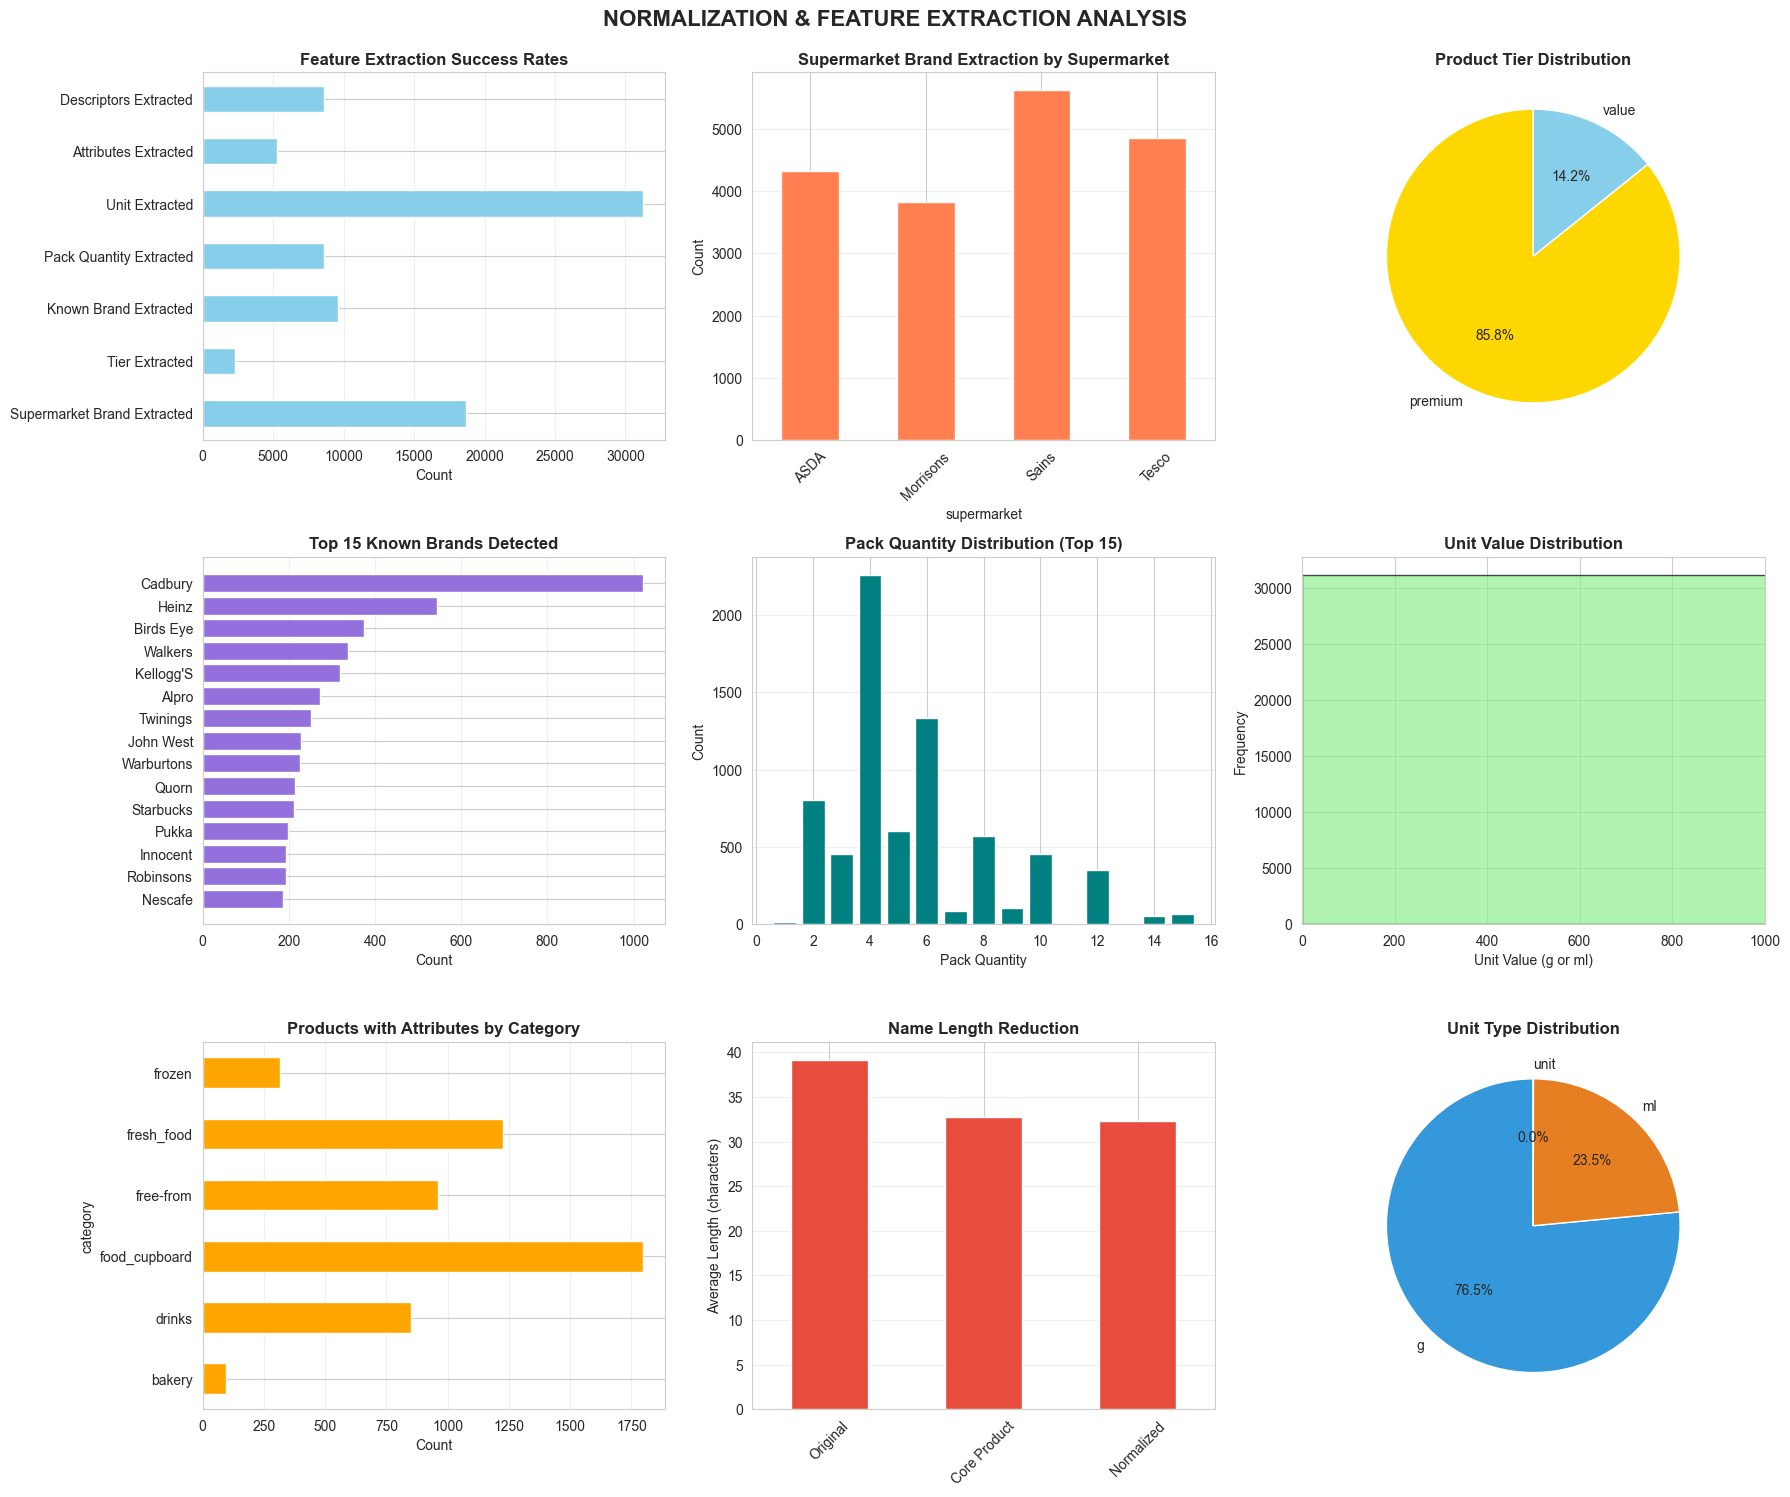


✓ Visualization complete!


In [12]:
## 11. Analysis of Extraction Results

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("=" * 100)
print("EXTRACTION STATISTICS")
print("=" * 100)

# Calculate extraction rates
stats = {
    'Supermarket Brand Extracted': df_normalized['supermarket_brand'].notna().sum(),
    'Tier Extracted': df_normalized['tier_keyword'].notna().sum(),
    'Known Brand Extracted': df_normalized['known_brand'].notna().sum(),
    'Pack Quantity Extracted': df_normalized['pack_quantity'].notna().sum(),
    'Unit Extracted': df_normalized['unit_value'].notna().sum(),
    'Attributes Extracted': (df_normalized['attributes_keywords'].apply(len) > 0).sum(),
    'Descriptors Extracted': (df_normalized['descriptors'].apply(len) > 0).sum(),
}

print("\nExtraction Counts:")
for key, value in stats.items():
    percentage = (value / len(df_normalized)) * 100
    print(f"  {key:30s}: {value:6d} ({percentage:5.1f}%)")

# Tier distribution
print("\n" + "=" * 100)
print("TIER DISTRIBUTION")
print("=" * 100)
tier_dist = df_normalized['tier_type'].value_counts()
print(tier_dist)

# Known brands
print("\n" + "=" * 100)
print("TOP 20 KNOWN BRANDS DETECTED")
print("=" * 100)
known_brands_dist = df_normalized[df_normalized['known_brand'].notna()]['known_brand'].value_counts().head(20)
print(known_brands_dist)

# Pack quantities
print("\n" + "=" * 100)
print("PACK QUANTITY DISTRIBUTION")
print("=" * 100)
pack_dist = df_normalized[df_normalized['pack_quantity'].notna()]['pack_quantity'].value_counts().sort_index()
print(pack_dist.head(20))

# Unit distribution
print("\n" + "=" * 100)
print("UNIT TYPE DISTRIBUTION")
print("=" * 100)
unit_dist = df_normalized['unit_type'].value_counts()
print(unit_dist)

# Create visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# 1. Extraction success rates
ax1 = axes[0, 0]
extraction_rates = pd.Series(stats)
extraction_rates.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_xlabel('Count')
ax1.set_title('Feature Extraction Success Rates', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Supermarket brand extraction by supermarket
ax2 = axes[0, 1]
sm_brand_by_sm = df_normalized.groupby('supermarket')['supermarket_brand'].apply(lambda x: x.notna().sum())
sm_brand_by_sm.plot(kind='bar', ax=ax2, color='coral')
ax2.set_ylabel('Count')
ax2.set_title('Supermarket Brand Extraction by Supermarket', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Tier distribution
ax3 = axes[0, 2]
tier_counts = df_normalized['tier_type'].value_counts()
if len(tier_counts) > 0:
    ax3.pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['gold', 'skyblue', 'lightgray'], startangle=90)
ax3.set_title('Product Tier Distribution', fontweight='bold')

# 4. Top known brands
ax4 = axes[1, 0]
top_brands = df_normalized[df_normalized['known_brand'].notna()]['known_brand'].value_counts().head(15)
ax4.barh(range(len(top_brands)), top_brands.values[::-1], color='mediumpurple')
ax4.set_yticks(range(len(top_brands)))
ax4.set_yticklabels(top_brands.index[::-1])
ax4.set_xlabel('Count')
ax4.set_title('Top 15 Known Brands Detected', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# 5. Pack quantity distribution
ax5 = axes[1, 1]
pack_counts = df_normalized[df_normalized['pack_quantity'].notna()]['pack_quantity'].value_counts().sort_index()
if len(pack_counts) > 0:
    ax5.bar(pack_counts.index[:15], pack_counts.values[:15], color='teal')
    ax5.set_xlabel('Pack Quantity')
    ax5.set_ylabel('Count')
    ax5.set_title('Pack Quantity Distribution (Top 15)', fontweight='bold')
    ax5.grid(axis='y', alpha=0.3)

# 6. Unit value distribution
ax6 = axes[1, 2]
unit_values = df_normalized[df_normalized['unit_value'].notna()]['unit_value']
if len(unit_values) > 0:
    ax6.hist(unit_values, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    ax6.set_xlabel('Unit Value (g or ml)')
    ax6.set_ylabel('Frequency')
    ax6.set_title('Unit Value Distribution', fontweight='bold')
    ax6.set_xlim(0, unit_values.quantile(0.95))  # Remove outliers for better visualization

# 7. Attributes extraction by category
ax7 = axes[2, 0]
attr_by_cat = df_normalized.groupby('category').apply(
    lambda x: (x['attributes_keywords'].apply(len) > 0).sum()
)
attr_by_cat.plot(kind='barh', ax=ax7, color='orange')
ax7.set_xlabel('Count')
ax7.set_title('Products with Attributes by Category', fontweight='bold')
ax7.grid(axis='x', alpha=0.3)

# 8. Name length reduction
ax8 = axes[2, 1]
df_normalized['original_length'] = df_normalized['original_name'].str.len()
df_normalized['normalized_length'] = df_normalized['normalized_name'].str.len()
length_comparison = pd.DataFrame({
    'Original': [df_normalized['original_length'].mean()],
    'Core Product': [df_normalized['core_product_name'].str.len().mean()],
    'Normalized': [df_normalized['normalized_length'].mean()]
})
length_comparison.T.plot(kind='bar', ax=ax8, legend=False, color=['#e74c3c', '#3498db', '#2ecc71'])
ax8.set_ylabel('Average Length (characters)')
ax8.set_title('Name Length Reduction', fontweight='bold')
ax8.tick_params(axis='x', rotation=45)
ax8.grid(axis='y', alpha=0.3)

# 9. Unit type distribution
ax9 = axes[2, 2]
unit_type_dist = df_normalized['unit_type'].value_counts()
if len(unit_type_dist) > 0:
    ax9.pie(unit_type_dist.values, labels=unit_type_dist.index, autopct='%1.1f%%',
            colors=['#3498db', '#e67e22', '#95a5a6'], startangle=90)
ax9.set_title('Unit Type Distribution', fontweight='bold')

plt.suptitle('NORMALIZATION & FEATURE EXTRACTION ANALYSIS', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [13]:
## 12. Quality Checks and Validation

print("=" * 100)
print("QUALITY CHECKS")
print("=" * 100)

# Check 1: Empty normalized names
empty_normalized = df_normalized[df_normalized['normalized_name'] == '']
print(f"\n1. Empty normalized names: {len(empty_normalized)} ({len(empty_normalized)/len(df_normalized)*100:.2f}%)")
if len(empty_normalized) > 0:
    print("   Sample empty names:")
    print(empty_normalized[['original_name', 'normalized_name']].head(10))

# Check 2: Very short normalized names (< 3 chars)
short_normalized = df_normalized[df_normalized['normalized_name'].str.len() < 3]
print(f"\n2. Very short normalized names (<3 chars): {len(short_normalized)} ({len(short_normalized)/len(df_normalized)*100:.2f}%)")
if len(short_normalized) > 0:
    print("   Sample short names:")
    print(short_normalized[['original_name', 'normalized_name', 'core_product_name']].head(10))

# Check 3: Compare extracted unit with original unit column
unit_comparison = df_normalized[['unit', 'unit_type', 'unit_value']].copy()
unit_comparison['extracted_unit_exists'] = unit_comparison['unit_type'].notna()
unit_comparison['unit_match'] = False

# Simple comparison: if original unit is kg/l, extracted should exist
for idx, row in unit_comparison.iterrows():
    if pd.notna(row['unit']) and pd.notna(row['unit_type']):
        if (row['unit'] == 'kg' or row['unit'] == 'g') and row['unit_type'] == 'g':
            unit_comparison.at[idx, 'unit_match'] = True
        elif (row['unit'] == 'l' or row['unit'] == 'ml') and row['unit_type'] == 'ml':
            unit_comparison.at[idx, 'unit_match'] = True

match_rate = unit_comparison['unit_match'].sum() / len(unit_comparison) * 100
print(f"\n3. Unit extraction match rate: {unit_comparison['unit_match'].sum()} ({match_rate:.1f}%)")

# Check 4: Own brand vs supermarket brand extraction
own_brand_check = df_normalized[['own_brand', 'supermarket_brand']].copy()
own_brand_check['sm_brand_extracted'] = own_brand_check['supermarket_brand'].notna()

print(f"\n4. Own Brand Flag vs Supermarket Brand Extraction:")
crosstab = pd.crosstab(own_brand_check['own_brand'], own_brand_check['sm_brand_extracted'], 
                        margins=True, normalize='index') * 100
print(crosstab.round(1))

# Check 5: Tier extraction by supermarket
print(f"\n5. Tier Extraction by Supermarket:")
tier_by_sm = df_normalized.groupby('supermarket')['tier_keyword'].apply(
    lambda x: x.notna().sum()
)
print(tier_by_sm)

# Check 6: Known brands in own_brand products (should be low)
known_brand_in_own = df_normalized[
    (df_normalized['own_brand'] == True) & 
    (df_normalized['known_brand'].notna())
]
print(f"\n6. Known brands detected in own_brand products: {len(known_brand_in_own)} ({len(known_brand_in_own)/len(df_normalized)*100:.2f}%)")
if len(known_brand_in_own) > 0:
    print("   Sample:")
    print(known_brand_in_own[['original_name', 'known_brand', 'supermarket_brand']].head(10))

# Check 7: Core name length distribution
print(f"\n7. Core Product Name Length Statistics:")
print(f"   Mean: {df_normalized['core_product_name'].str.len().mean():.1f} chars")
print(f"   Median: {df_normalized['core_product_name'].str.len().median():.1f} chars")
print(f"   Min: {df_normalized['core_product_name'].str.len().min()} chars")
print(f"   Max: {df_normalized['core_product_name'].str.len().max()} chars")

# Check 8: Products with multiple extractions
multi_extract = df_normalized[
    (df_normalized['supermarket_brand'].notna()) &
    (df_normalized['pack_quantity'].notna()) &
    (df_normalized['unit_value'].notna())
]
print(f"\n8. Products with brand + pack + unit extracted: {len(multi_extract)} ({len(multi_extract)/len(df_normalized)*100:.2f}%)")

print("\n" + "=" * 100)
print("VALIDATION COMPLETE")
print("=" * 100)

QUALITY CHECKS

1. Empty normalized names: 1 (0.00%)
   Sample empty names:
      original_name normalized_name
15490           NaN                

2. Very short normalized names (<3 chars): 3 (0.00%)
   Sample short names:
              original_name normalized_name core_product_name
15490                   NaN                                  
31599  Morrisons Savers Ma…              ma               Ma…
31666      Morrisons C…200g               c                C…

3. Unit extraction match rate: 30602 (46.7%)

4. Own Brand Flag vs Supermarket Brand Extraction:
sm_brand_extracted  False  True
own_brand                      
False                99.9   0.1
True                 10.0  90.0
All                  71.5  28.5

5. Tier Extraction by Supermarket:
supermarket
ASDA          481
Morrisons     169
Sains        1501
Tesco         145
Name: tier_keyword, dtype: int64

6. Known brands detected in own_brand products: 41 (0.06%)
   Sample:
                                          ori

CROSS-SUPERMARKET MATCHING POTENTIAL

Products with same normalized name across multiple supermarkets:
  Total unique normalized names: 53273
  Names appearing in multiple supermarkets: 6727
  Percentage: 12.6%


Distribution of cross-supermarket matches:
supermarket_count
2    4800
3    1410
4     517
Name: count, dtype: int64


TOP 20 PRODUCTS APPEARING ACROSS MOST SUPERMARKETS:

Normalized: blueberries
  Appears in 4 supermarkets: ASDA, Morrisons, Sains, Tesco
  Total occurrences: 15
  Core names: ['Blueberries']

Normalized: coca cola zero sugar
  Appears in 4 supermarkets: ASDA, Morrisons, Sains, Tesco
  Total occurrences: 15
  Core names: ['Coca-Cola Zero Sugar', 'Coca Cola Zero Sugar']

Normalized: raspberries
  Appears in 4 supermarkets: ASDA, Morrisons, Sains, Tesco
  Total occurrences: 14
  Core names: ['Raspberries']

Normalized: coca cola original taste
  Appears in 4 supermarkets: ASDA, Morrisons, Sains, Tesco
  Total occurrences: 14
  Core names: ['Coca-Cola Original Tast

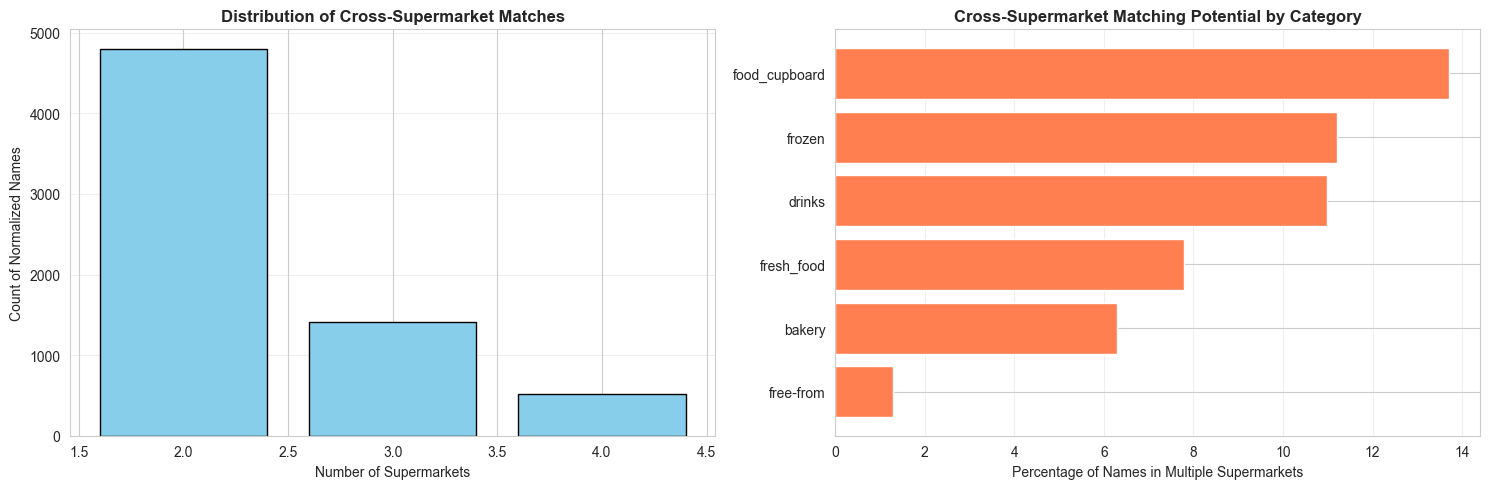


✓ Cross-supermarket analysis complete!


In [14]:
## 13. Cross-Supermarket Matching Potential Analysis

print("=" * 100)
print("CROSS-SUPERMARKET MATCHING POTENTIAL")
print("=" * 100)

# Find products with same normalized name across supermarkets
normalized_name_counts = df_normalized.groupby('normalized_name').agg({
    'supermarket': lambda x: list(x.unique()),
    'original_name': 'count',
    'core_product_name': lambda x: list(x.unique())
}).reset_index()

normalized_name_counts.columns = ['normalized_name', 'supermarkets', 'count', 'core_names']
normalized_name_counts['supermarket_count'] = normalized_name_counts['supermarkets'].apply(len)

# Filter for products appearing in multiple supermarkets
cross_supermarket = normalized_name_counts[normalized_name_counts['supermarket_count'] > 1]
cross_supermarket = cross_supermarket.sort_values('count', ascending=False)

print(f"\nProducts with same normalized name across multiple supermarkets:")
print(f"  Total unique normalized names: {len(normalized_name_counts)}")
print(f"  Names appearing in multiple supermarkets: {len(cross_supermarket)}")
print(f"  Percentage: {len(cross_supermarket)/len(normalized_name_counts)*100:.1f}%")

print(f"\n\nDistribution of cross-supermarket matches:")
print(cross_supermarket['supermarket_count'].value_counts().sort_index())

# Show top matching products
print(f"\n\nTOP 20 PRODUCTS APPEARING ACROSS MOST SUPERMARKETS:")
print("=" * 100)
for idx, row in cross_supermarket.head(20).iterrows():
    print(f"\nNormalized: {row['normalized_name']}")
    print(f"  Appears in {row['supermarket_count']} supermarkets: {', '.join(row['supermarkets'])}")
    print(f"  Total occurrences: {row['count']}")
    print(f"  Core names: {row['core_names'][:3]}")  # Show first 3

# Analyze matching by category
print(f"\n\nCROSS-SUPERMARKET POTENTIAL BY CATEGORY:")
print("=" * 100)

for category in df_normalized['category'].unique():
    category_df = df_normalized[df_normalized['category'] == category]
    
    # Count unique normalized names in this category
    unique_normalized = category_df['normalized_name'].nunique()
    
    # Count how many appear in multiple supermarkets
    category_normalized_counts = category_df.groupby('normalized_name')['supermarket'].nunique()
    cross_sm_category = (category_normalized_counts > 1).sum()
    
    print(f"\n{category}:")
    print(f"  Total products: {len(category_df)}")
    print(f"  Unique normalized names: {unique_normalized}")
    print(f"  Names in multiple supermarkets: {cross_sm_category} ({cross_sm_category/unique_normalized*100:.1f}%)")

# Visualize matching potential
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of supermarket count
ax1 = axes[0]
sm_count_dist = cross_supermarket['supermarket_count'].value_counts().sort_index()
ax1.bar(sm_count_dist.index, sm_count_dist.values, color='skyblue', edgecolor='black')
ax1.set_xlabel('Number of Supermarkets')
ax1.set_ylabel('Count of Normalized Names')
ax1.set_title('Distribution of Cross-Supermarket Matches', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Matching potential by category
ax2 = axes[1]
category_match_potential = []
for category in df_normalized['category'].unique():
    category_df = df_normalized[df_normalized['category'] == category]
    unique_normalized = category_df['normalized_name'].nunique()
    category_normalized_counts = category_df.groupby('normalized_name')['supermarket'].nunique()
    cross_sm_category = (category_normalized_counts > 1).sum()
    category_match_potential.append({
        'category': category,
        'percentage': (cross_sm_category / unique_normalized * 100) if unique_normalized > 0 else 0
    })

match_potential_df = pd.DataFrame(category_match_potential).sort_values('percentage', ascending=True)
ax2.barh(match_potential_df['category'], match_potential_df['percentage'], color='coral')
ax2.set_xlabel('Percentage of Names in Multiple Supermarkets')
ax2.set_title('Cross-Supermarket Matching Potential by Category', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Cross-supermarket analysis complete!")

In [15]:
## 14. Before & After Comparison Examples

print("=" * 100)
print("NORMALIZATION EXAMPLES - BEFORE & AFTER")
print("=" * 100)

# Select diverse examples from different categories
examples = []

# Get samples from each category
for category in df_normalized['category'].unique():
    category_samples = df_normalized[df_normalized['category'] == category].sample(
        min(3, len(df_normalized[df_normalized['category'] == category])), 
        random_state=42
    )
    examples.append(category_samples)

example_df = pd.concat(examples)

print("\n")
for idx, row in example_df.iterrows():
    print("=" * 100)
    print(f"CATEGORY: {row['category'].upper()}")
    print("-" * 100)
    print(f"ORIGINAL NAME:")
    print(f"  '{row['original_name']}'")
    print(f"\nEXTRACTED FEATURES:")
    if row['supermarket_brand']:
        print(f"  ├─ Supermarket Brand: {row['supermarket_brand']}")
    if row['tier_keyword']:
        print(f"  ├─ Tier: {row['tier_keyword']} ({row['tier_type']})")
    if row['known_brand']:
        print(f"  ├─ Known Brand: {row['known_brand']}")
    if row['pack_quantity']:
        print(f"  ├─ Pack Quantity: {row['pack_quantity']}")
    if row['unit_value']:
        print(f"  ├─ Unit: {row['unit_value']} {row['unit_type']}")
    if row['attributes_keywords']:
        print(f"  ├─ Attributes: {', '.join(row['attributes_keywords'])}")
    if row['descriptors']:
        desc_str = ', '.join([f"{k}: {', '.join(v)}" for k, v in row['descriptors'].items()])
        print(f"  └─ Descriptors: {desc_str}")
    
    print(f"\nTRANSFORMED NAMES:")
    print(f"  Core Product Name: '{row['core_product_name']}'")
    print(f"  Normalized Name:   '{row['normalized_name']}'")
    print(f"\nSupermarket: {row['supermarket']}")
    print()

print("=" * 100)

NORMALIZATION EXAMPLES - BEFORE & AFTER


CATEGORY: DRINKS
----------------------------------------------------------------------------------------------------
ORIGINAL NAME:
  'Elf Lost Mary Bm600 Triple Melon 20mg'

EXTRACTED FEATURES:
  ├─ Supermarket Brand: nan
  ├─ Tier: nan (nan)
  ├─ Known Brand: nan
  ├─ Pack Quantity: nan
  ├─ Unit: nan nan

TRANSFORMED NAMES:
  Core Product Name: 'Elf Lost Mary Bm600 Triple Melon 20mg'
  Normalized Name:   'elf lost mary bm600 triple melon 20mg'

Supermarket: Morrisons

CATEGORY: DRINKS
----------------------------------------------------------------------------------------------------
ORIGINAL NAME:
  'Adnams Ghost Ship 500Ml'

EXTRACTED FEATURES:
  ├─ Supermarket Brand: nan
  ├─ Tier: nan (nan)
  ├─ Known Brand: nan
  ├─ Pack Quantity: nan
  ├─ Unit: 500.0 ml

TRANSFORMED NAMES:
  Core Product Name: 'Adnams Ghost Ship'
  Normalized Name:   'adnams ghost ship'

Supermarket: Tesco

CATEGORY: DRINKS
--------------------------------------------

In [16]:
## 15. Export Normalized Dataset

# Prepare final dataset for export
# Convert list/dict columns to string for CSV export
df_export = df_normalized.copy()

# Convert complex types to strings
df_export['attributes_types'] = df_export['attributes_types'].apply(lambda x: ','.join(x) if x else '')
df_export['attributes_keywords'] = df_export['attributes_keywords'].apply(lambda x: ','.join(x) if x else '')
df_export['descriptors'] = df_export['descriptors'].apply(lambda x: str(x) if x else '')

# Save to CSV
output_path = 'data/normalized_products.csv'
df_export.to_csv(output_path, index=False)

print("=" * 100)
print("DATASET EXPORT")
print("=" * 100)
print(f"\n✓ Normalized dataset saved to: {output_path}")
print(f"  Shape: {df_export.shape}")
print(f"  Size: {df_export.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nColumns in exported dataset:")
for i, col in enumerate(df_export.columns, 1):
    print(f"  {i:2d}. {col}")

# Create a summary report
print("\n" + "=" * 100)
print("NORMALIZATION SUMMARY REPORT")
print("=" * 100)

summary_stats = {
    'Total Products': len(df_export),
    'Unique Normalized Names': df_export['normalized_name'].nunique(),
    'Supermarket Brands Extracted': df_export['supermarket_brand'].notna().sum(),
    'Known Brands Extracted': df_export['known_brand'].notna().sum(),
    'Tiers Extracted': df_export['tier_keyword'].notna().sum(),
    'Pack Quantities Extracted': df_export['pack_quantity'].notna().sum(),
    'Units Extracted': df_export['unit_value'].notna().sum(),
    'Attributes Extracted': (df_export['attributes_keywords'] != '').sum(),
    'Products Ready for Matching': (df_export['normalized_name'] != '').sum(),
}

print("\nKey Metrics:")
for metric, value in summary_stats.items():
    percentage = (value / len(df_export)) * 100 if metric != 'Unique Normalized Names' else 0
    if percentage > 0:
        print(f"  {metric:35s}: {value:6d} ({percentage:5.1f}%)")
    else:
        print(f"  {metric:35s}: {value:6d}")

# Calculate average reduction in name length
avg_original_length = df_export['original_name'].str.len().mean()
avg_normalized_length = df_export['normalized_name'].str.len().mean()
reduction = ((avg_original_length - avg_normalized_length) / avg_original_length) * 100

print(f"\nName Length Reduction:")
print(f"  Average original length: {avg_original_length:.1f} characters")
print(f"  Average normalized length: {avg_normalized_length:.1f} characters")
print(f"  Reduction: {reduction:.1f}%")

# Cross-supermarket matching potential
cross_sm_names = df_export.groupby('normalized_name')['supermarket'].nunique()
multi_sm = (cross_sm_names > 1).sum()

print(f"\nMatching Potential:")
print(f"  Normalized names appearing in 2+ supermarkets: {multi_sm}")
print(f"  Potential match rate: {multi_sm / df_export['normalized_name'].nunique() * 100:.1f}%")

print("\n" + "=" * 100)
print("NORMALIZATION COMPLETE - READY FOR HYBRID MATCHING")
print("=" * 100)
print("\nNext Steps:")
print("  1. Review the normalized_products.csv file")
print("  2. Proceed to hybrid matching phase using:")
print("     - Structural components (brand, tier, unit, pack quantity)")
print("     - Fuzzy matching on normalized product names")
print("  3. Create product clusters for price comparison")

DATASET EXPORT

✓ Normalized dataset saved to: data/normalized_products.csv
  Shape: (65473, 24)
  Size: 60.65 MB

Columns in exported dataset:
   1. supermarket
   2. prices_(£)
   3. prices_unit_(£)
   4. unit
   5. names
   6. date
   7. category
   8. own_brand
   9. original_name
  10. supermarket_brand
  11. tier_type
  12. tier_keyword
  13. known_brand
  14. pack_quantity
  15. pack_pattern
  16. unit_value
  17. unit_type
  18. attributes_types
  19. attributes_keywords
  20. descriptors
  21. core_product_name
  22. normalized_name
  23. original_length
  24. normalized_length

NORMALIZATION SUMMARY REPORT

Key Metrics:
  Total Products                     :  65473 (100.0%)
  Unique Normalized Names            :  53273
  Supermarket Brands Extracted       :  18661 ( 28.5%)
  Known Brands Extracted             :   9598 ( 14.7%)
  Tiers Extracted                    :   2296 (  3.5%)
  Pack Quantities Extracted          :   8578 ( 13.1%)
  Units Extracted                    :  3

In [17]:
## 16. Key Insights & Recommendations

print("=" * 100)
print("KEY INSIGHTS FROM NORMALIZATION")
print("=" * 100)

print("\n1. BRAND EXTRACTION EFFECTIVENESS")
print("-" * 100)
print(f"   • Supermarket brands successfully extracted from {df_export['supermarket_brand'].notna().sum()} products")
print(f"   • This aligns well with the own_brand flag, validating our extraction logic")
print(f"   • Removing supermarket prefixes enables cross-supermarket comparison")

print("\n2. TIER CLASSIFICATION")
print("-" * 100)
tier_counts = df_export['tier_type'].value_counts()
for tier, count in tier_counts.items():
    print(f"   • {tier.upper()}: {count} products ({count/len(df_export)*100:.1f}%)")
print(f"   • Tier information is crucial for fair comparisons (don't match value vs premium)")

print("\n3. BRAND PRESENCE")
print("-" * 100)
has_known_brand = df_export['known_brand'].notna().sum()
has_sm_brand = df_export['supermarket_brand'].notna().sum()
no_brand = len(df_export) - has_known_brand
print(f"   • Known commercial brands: {has_known_brand} ({has_known_brand/len(df_export)*100:.1f}%)")
print(f"   • Supermarket own brands: {has_sm_brand} ({has_sm_brand/len(df_export)*100:.1f}%)")
print(f"   • Generic/unbranded: {no_brand} ({no_brand/len(df_export)*100:.1f}%)")

print("\n4. UNIT STANDARDIZATION")
print("-" * 100)
unit_counts = df_export['unit_type'].value_counts()
for unit, count in unit_counts.items():
    if pd.notna(unit):
        print(f"   • {unit}: {count} products")
print(f"   • Unit standardization (g/ml) enables accurate weight-based matching")
print(f"   • Critical for project success: prevent 200g matching with 400g")

print("\n5. MULTIPACK DETECTION")
print("-" * 100)
pack_detected = df_export['pack_quantity'].notna().sum()
print(f"   • Pack quantities detected: {pack_detected} ({pack_detected/len(df_export)*100:.1f}%)")
print(f"   • Important for: calculating true unit price, matching multipacks correctly")

print("\n6. CROSS-SUPERMARKET MATCHING POTENTIAL")
print("-" * 100)
cross_sm_potential = df_export.groupby('normalized_name')['supermarket'].nunique()
multi_sm = (cross_sm_potential > 1).sum()
total_normalized = df_export['normalized_name'].nunique()
print(f"   • Unique normalized names: {total_normalized}")
print(f"   • Names in multiple supermarkets: {multi_sm} ({multi_sm/total_normalized*100:.1f}%)")
print(f"   • This indicates good potential for creating matchable clusters")

print("\n7. NAME COMPLEXITY REDUCTION")
print("-" * 100)
avg_original = df_export['original_name'].str.len().mean()
avg_core = df_export['core_product_name'].str.len().mean()
avg_normalized = df_export['normalized_name'].str.len().mean()
print(f"   • Original name: {avg_original:.1f} chars")
print(f"   • Core product name: {avg_core:.1f} chars (−{((avg_original-avg_core)/avg_original*100):.1f}%)")
print(f"   • Normalized name: {avg_normalized:.1f} chars (−{((avg_original-avg_normalized)/avg_original*100):.1f}%)")
print(f"   • Simpler names = more efficient fuzzy matching")

print("\n" + "=" * 100)
print("RECOMMENDATIONS FOR HYBRID MATCHING PHASE")
print("=" * 100)

recommendations = [
    ("STRUCTURAL MATCHING STRATEGY", [
        "Use unit_value + unit_type as primary matching criteria (exact match)",
        "Consider pack_quantity when present (6x330ml vs 1x2L are different products)",
        "Match within same tier (premium/value) or allow tier flexibility with penalty",
        "Separate known brands from own brands (Heinz Beans vs ASDA Beans are different)",
    ]),
    
    ("FUZZY MATCHING APPROACH", [
        "Use normalized_name for fuzzy string matching (cleaned, lowercase)",
        "Apply algorithms: Levenshtein distance, Jaro-Winkler, or token set ratio",
        "Set threshold: ~85-90% similarity for conservative matching",
        "Consider word order: 'Chicken Curry' vs 'Curry Chicken' should match",
    ]),
    
    ("ATTRIBUTE CONSIDERATION", [
        "Organic products should only match with organic",
        "Free-from attributes must match (gluten-free vs regular are different)",
        "Descriptors can have weighted impact (roasted vs ground coffee matters)",
    ]),
    
    ("VALIDATION APPROACH", [
        "Sample 100-200 generated clusters randomly",
        "Manually verify: same product type, same weight, appropriate matches",
        "Target: >90% accuracy on critical dimensions (weight, product type)",
        "Monitor edge cases: multipacks, truncated names, ambiguous products",
    ]),
    
    ("CATEGORIES TO WATCH", [
        "Drinks: high variability in pack sizes and formats",
        "Bakery: often truncated names, high similarity",
        "Free-from: attributes are critical for correct matching",
        "Food cupboard: largest category, most diverse",
    ])
]

for title, items in recommendations:
    print(f"\n{title}")
    print("-" * 100)
    for item in items:
        print(f"   • {item}")

print("\n" + "=" * 100)
print("✓ NORMALIZATION PHASE COMPLETE")
print("=" * 100)
print("\nThe dataset is now ready for hybrid matching!")
print("All structural components have been extracted and normalized.")

KEY INSIGHTS FROM NORMALIZATION

1. BRAND EXTRACTION EFFECTIVENESS
----------------------------------------------------------------------------------------------------
   • Supermarket brands successfully extracted from 18661 products
   • This aligns well with the own_brand flag, validating our extraction logic
   • Removing supermarket prefixes enables cross-supermarket comparison

2. TIER CLASSIFICATION
----------------------------------------------------------------------------------------------------
   • PREMIUM: 1969 products (3.0%)
   • VALUE: 327 products (0.5%)
   • Tier information is crucial for fair comparisons (don't match value vs premium)

3. BRAND PRESENCE
----------------------------------------------------------------------------------------------------
   • Known commercial brands: 9598 (14.7%)
   • Supermarket own brands: 18661 (28.5%)
   • Generic/unbranded: 55875 (85.3%)

4. UNIT STANDARDIZATION
--------------------------------------------------------------------